# BTSP in an open field with a corridor (2-comp)

In [1]:
import copy
import importlib
from pathlib import Path
import time
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from ratinabox import utils as rutils
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons, value_neurons
from predhpc.util import gen_util, ext_util, learn_util, params_util, plot_util, animate_util

%load_ext autoreload

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "openfield_corridor"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## Initialise parameters

In [5]:
RECORD_WEIGHTS_FREQ = 1000
MAX_NUM_STEPS = 15000
USE_HEBBIAN = False

locations = {
    "start": [0.2, 0.8],
    "reward": [0.25, 0.1],
    "novel": [0.9, 0.9],
    "teleport_in_out": [[0.6, 0.5], [0.2, 0.1]],
    "wall_coords": [[0, 0.2], [0.6, 0.2]],
}
locations = {key: np.asarray(data) * params_util.SCALE for key, data in locations.items()}

env_params = params_util.get_env_params(
    environment="openfield",
    init_random_reward_obj=0,
    init_random_novel_obj=0,
    init_random_walls=0,
    init_random_teleport_pairs=0,
    walls=copy.deepcopy([locations["wall_coords"]]),
    init_reward_obj=copy.deepcopy([locations["reward"]]),
    init_novel_obj=copy.deepcopy([locations["novel"]]),
    init_teleport_pairs=copy.deepcopy([locations["teleport_in_out"]]),
)

agent_params = params_util.get_agent_params(
    environment="openfield",
    reward_factor=10,
    no_target_factor=1,
)

Obj_params = params_util.get_Obj_params(
    environment="openfield",
    num_novel=0,
    num_teleport=0,
    num_reward=1,
    )

PC_params = params_util.get_PC_params(
    environment="openfield",
)

VN_params = {
    "n": 1,
    "peak": copy.deepcopy(locations["reward"]),
    "description": "gaussian",
    "max_fr": 10,
    "widths": 0.6,
}

Pyr_params = params_util.get_Pyr_params(
    n=1, 
    environment="openfield",
    log_BTSP=True,
)

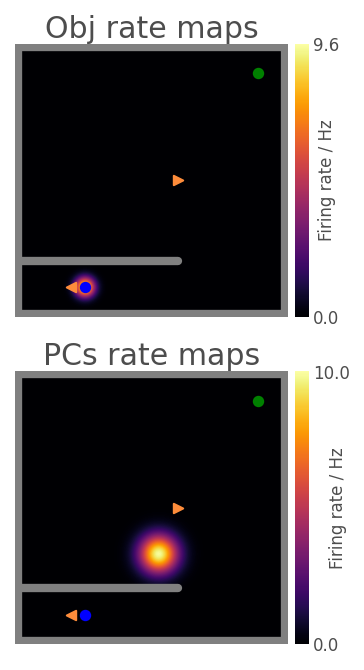

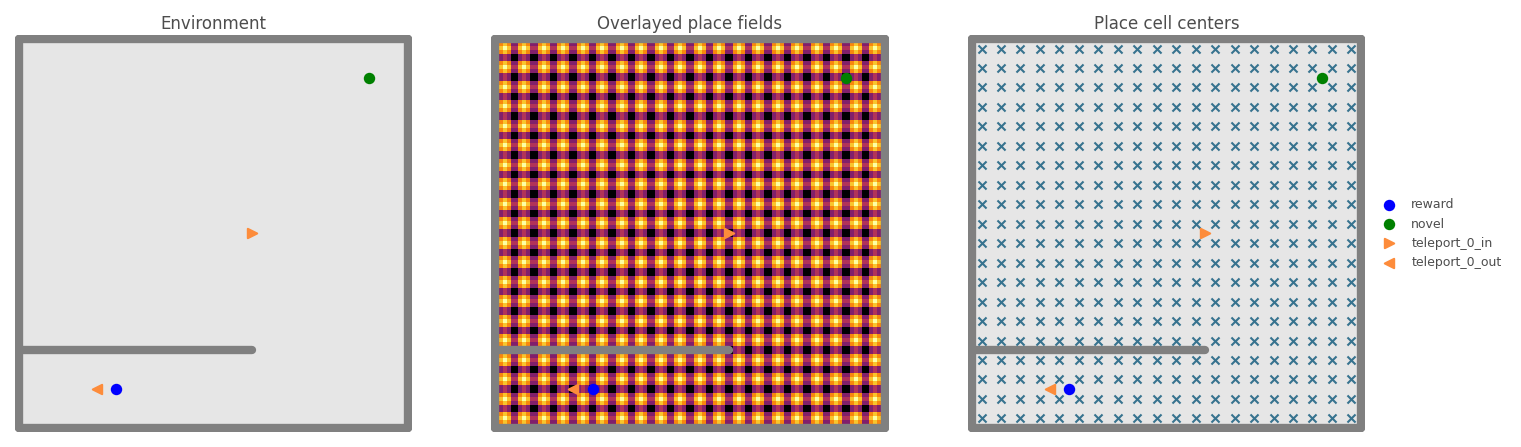

In [6]:
Pyrs, fields_axes, aggreg_ax1D = run_manager.init_env_objects(
    env_params=env_params,
    agent_params=agent_params,
    PC_params=PC_params,
    Pyr_params=Pyr_params,
    Obj_params=Obj_params,
    environment="openfield",
    plot=True
)

Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(Pyrs)

VN = value_neurons.SimpleValueNeuron(Ag, params=VN_params)

ALL_FIGURES["fields"] = fields_axes
ALL_FIGURES["fields_aggreg"] = aggreg_ax1D

Target is reward: True.


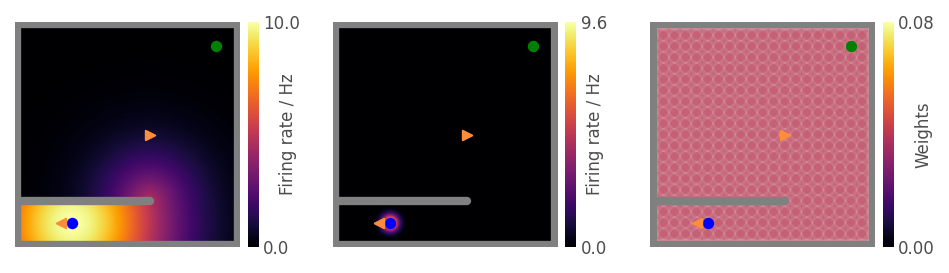

In [7]:
Ag.pos = copy.deepcopy(locations["start"])
Ag.head_direction = np.asarray([-1, 0])
Ag.allow_teleportation(False) # prevent teleportation for now
target_is_reward = Ag.target_position is not None and (Ag.target_position == copy.deepcopy(locations["reward"])).all()
print(f"Target is reward: {target_is_reward}.")

Pyrs.set_learn(False)
Pyrs.set_BTSP_learn(False)

_, ax1D = plt.subplots(1, 3, figsize=(6, 1.5))
VN.plot_rate_map(no_legend=True, ax=ax1D[0])

Objs.plot_rate_map(no_legend=True, ax=ax1D[1])

plot_fcts.plot_2D_input_place_cell_weights(
    Pyrs.SomaCompartment, alpha=0.3, s=120, mark_BTSP=False, no_legend=True, ax=ax1D[2]
)

ALL_FIGURES["field_summary"] = ax1D

## Create an updater class

In [8]:
class VNUpdater():

    def __init__(self, Ag, VN, thresh_gradV=0.2, drift_vel_fact=3, drift_to_random_strength_ratio=0.2):
        self.Ag = Ag
        self.VN = VN
        self.thresh_gradV = thresh_gradV
        self.drift_vel_fact = drift_vel_fact
        self.drift_to_random_strength_ratio = drift_to_random_strength_ratio

    def get_update_kwargs(self):
        self.VN.update()
        drift_velocity = None
        if self.Ag.target_position is not None and (self.Ag.target_position == self.VN.peak).all():
            gradV = self.VN.get_local_gradient(thresh_gradV=self.thresh_gradV)
            if gradV is not None: 
                drift_velocity = self.drift_vel_fact * self.Ag.speed_mean * gradV
        update_kwargs = {
            "drift_velocity": drift_velocity,
            "drift_to_random_strength_ratio": self.drift_to_random_strength_ratio,
        }

        return update_kwargs

## 1. Learn

In [9]:
updater = VNUpdater(Ag, VN)

learner = run_manager.learn_openfield_BTSP(
    Pyrs,
    use_Hebbian=USE_HEBBIAN,
    max_num_steps=MAX_NUM_STEPS,
    updater=updater
)

100%|████████████████████████████████████| 15000/15000 [00:44<00:00, 339.29it/s]

Reached target 61 times.
Trajectory lengths (8) to date: 56.25 +/- 9.92 sec each
Trajectory lengths (8) to date: 1875.00 +/- 330.72 steps each
1 BTSP events triggered (allowed from steps 0 to 14999): occurred at step 5947.


In [10]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
learner.Pyrs.SomaCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 696.00 steps (20.88 sec.)
No neuron had at least two BTSP events triggered.


In [11]:
Ag.log_teleportation()
Ag.trajectory_df

No teleportation events.


,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.137498,0.130678,0,0.0,1.104675,0.189006,2000.0,60.0,2000.0,60.0
1,1.362564,1.090573,2000,60.0,1.968567,0.189006,4000.0,120.0,2000.0,60.0
2,0.374496,1.232345,4000,120.0,0.440334,0.189006,6000.0,180.0,2000.0,60.0
3,0.749971,1.870146,6000,180.0,0.074189,0.189006,8000.0,240.0,2000.0,60.0
4,1.301454,1.345844,8000,240.0,0.447916,0.189006,10000.0,300.0,2000.0,60.0
5,1.864905,1.344223,10000,300.0,0.490932,0.189006,12000.0,360.0,2000.0,60.0
6,0.465889,0.515209,12000,360.0,0.819786,0.189006,14000.0,420.0,2000.0,60.0
7,0.363411,1.453561,14000,420.0,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
Ag.target_df.head()

,object_idx,object_type_name,object_type_num,position_x,position_y,set_step,set_time,random_walk_periods,reached_step,reached_time,num_random_walk_steps,random_walk_time,num_steps_total,time_total
0,0.0,reward,0.0,0.5,0.2,0,0.00,"[[0, 300], [300, 600], [600, 900], [900, 1200]]",1357.0,40.71,1200.0,36.00,1357.0,40.71
1,0.0,reward,0.0,0.5,0.2,1357,40.71,[],1358.0,40.74,0.0,0.00,1.0,0.03
2,0.0,reward,0.0,0.5,0.2,1358,40.74,[],1359.0,40.77,0.0,0.00,1.0,0.03
3,NaN,no_target,NaN,NaN,NaN,1359,40.77,"[[1359, 1659]]",NaN,NaN,300.0,9.00,300.0,9.00
4,0.0,reward,0.0,0.5,0.2,1659,49.77,"[[1942, 2000]]",NaN,NaN,58.0,1.74,341.0,10.23


Linear speed mean: 22.33 cm/s, std: 13.24 cm/s.


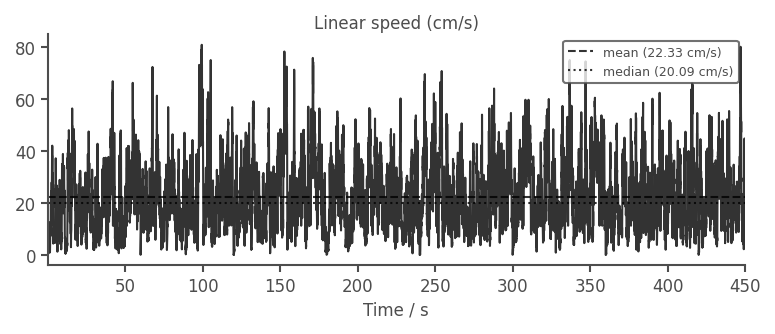

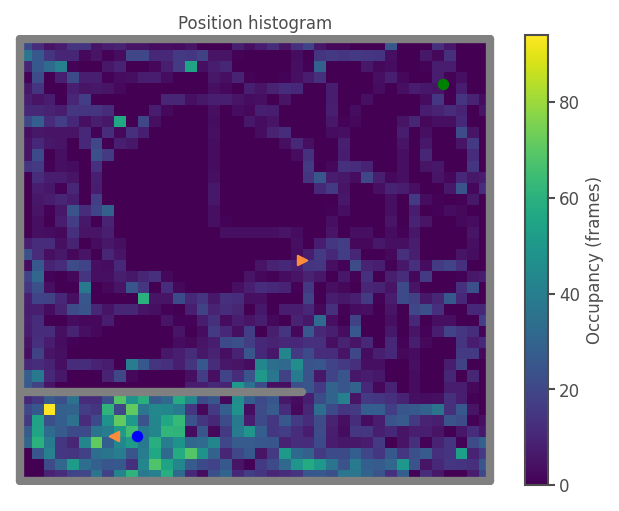

In [13]:
Ag.log_speed_stats()
sub_ax_speed = Ag.plot_speed(mark_mean=True, mark_median=True)
sub_ax_occ = Ag.plot_occupancy(no_legend=True)

ALL_FIGURES["1-initial_speed"] = sub_ax_speed
ALL_FIGURES["1-initial_occupancy"] = sub_ax_occ

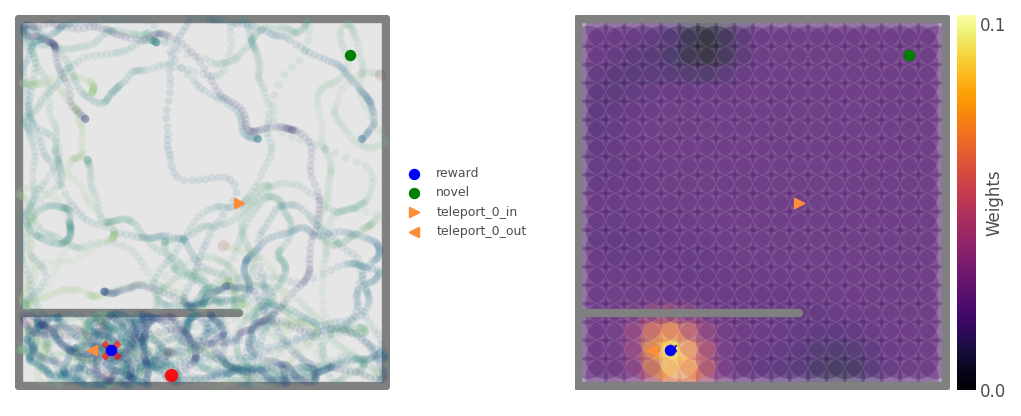

In [14]:
fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
Ag.plot_trajectories(alpha=0.1, sub_ax=ax1D[0])

plot_fcts.plot_2D_input_place_cell_weights(
    Pyrs.SomaCompartment, alpha=0.3, s=380, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
)

ALL_FIGURES["1-initial_spatial"] = ax1D

/home/cgillon/homedir/predhpc/predhpc/util/learn_util.py:816: UserWarning: Assessment will assume geodesic wall geometry even though place cell wall geometry is line_of_sight.
  warnings.warn(


Update 1 regul.: 1.0134 (w)


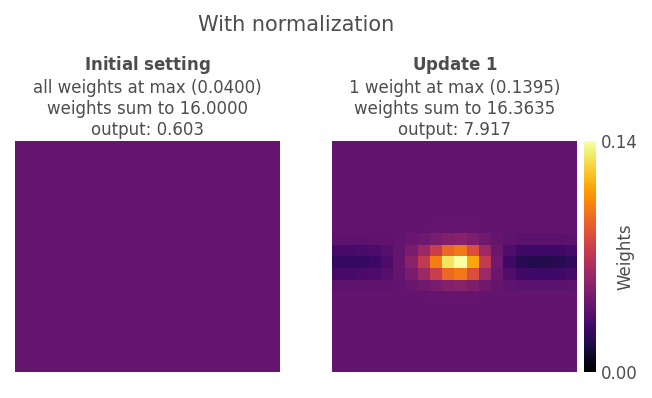

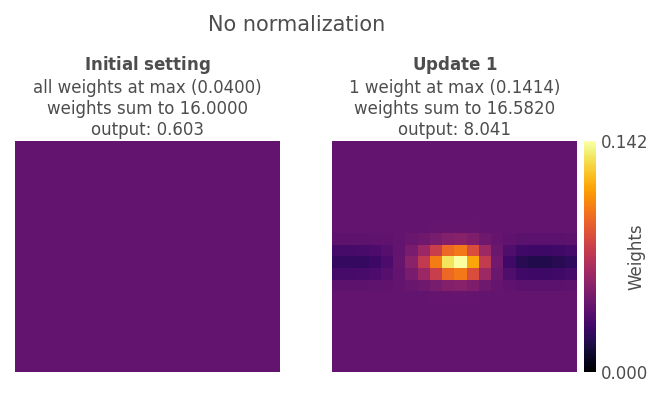

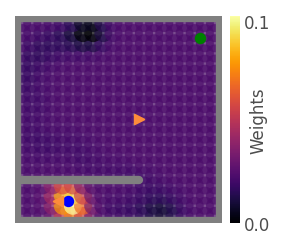

In [15]:
norm_theor_axes, no_norm_theor_axes, act_sub_ax = plot_fcts.compare_theoretical_and_true_weights(
    learner.Pyrs.SomaCompartment,
    output_fr=4.2, # tuned to match actual weights
)
act_sub_ax.get_legend().remove()

ALL_FIGURES["BTSP_kernel_norm"] = norm_theor_axes
ALL_FIGURES["BTSP_kernel"] = no_norm_theor_axes
ALL_FIGURES["1-initial_actual_weights"] = act_sub_ax

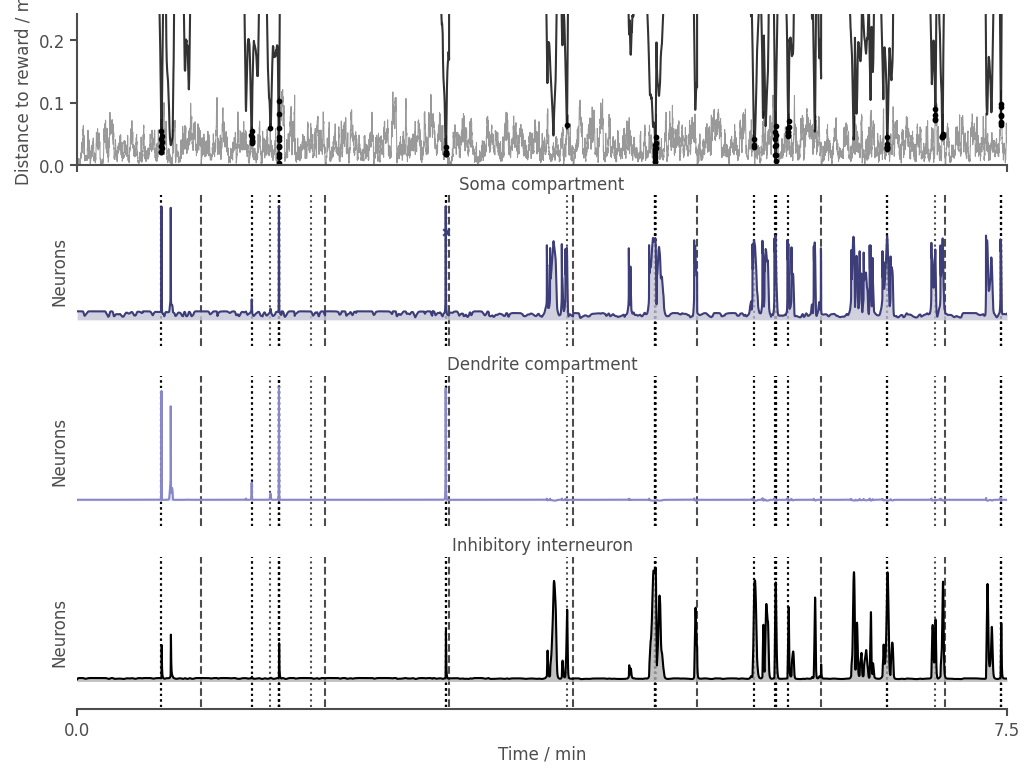

In [16]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

fig, ax1D = plt.subplots(4, 1, figsize=[8, 6], sharex=True)
Ag.plot_distance_to(
    position_name="reward", 
    position=copy.deepcopy(locations["reward"]), 
    mark_below_tolerance=True, 
    tol_prop_to_speed_dt=tol_prop_to_speed_dt,
    zoom_prop=2,
    sub_ax=ax1D[0]
    )
ax1D[0].set_xlabel("")
Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[1:])

ALL_FIGURES["1-initial_distance_to_target_single"] = ax1D

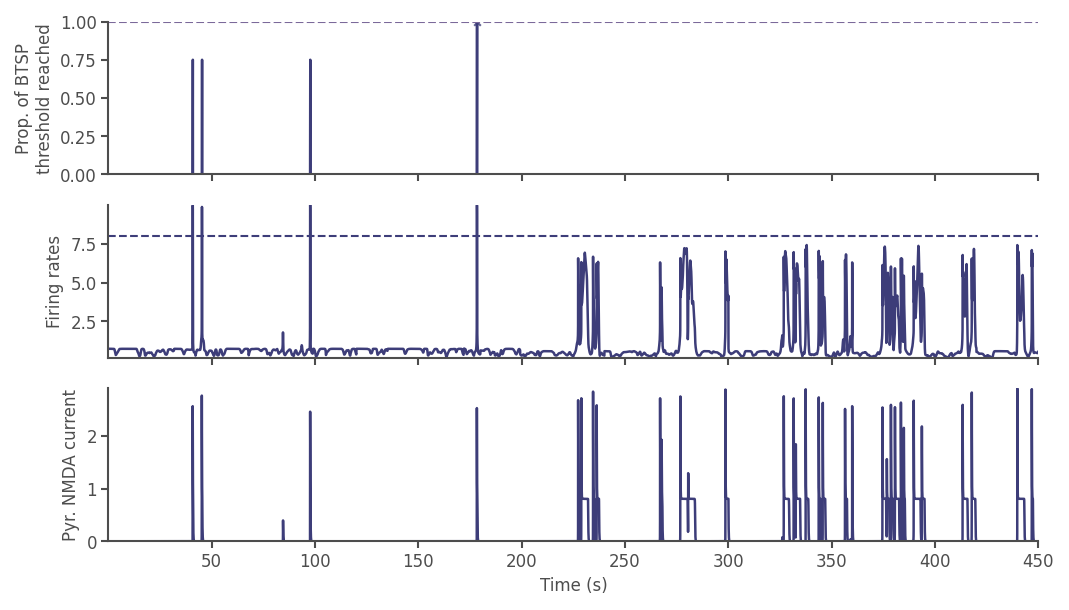

In [17]:
fig, ax1D = plt.subplots(3, 1, figsize=[8, 4.5], sharex=True)
Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D)

ALL_FIGURES["1-initial_BTSP_timeseries"] = ax1D

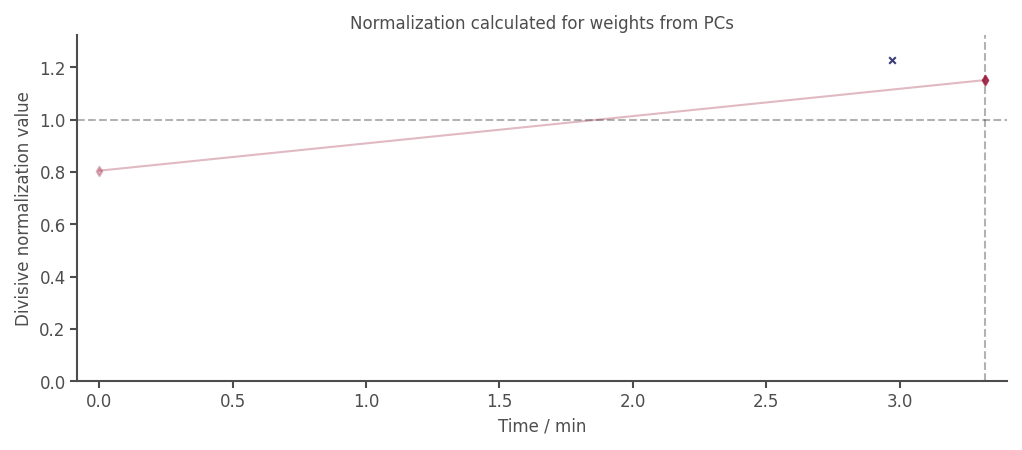

In [18]:
if learner.Pyrs.SomaCompartment.normalize_weights_divisively:
    sub_ax = learner.Pyrs.SomaCompartment.plot_normalization_values_over_time(input_layer="PCs")
    ALL_FIGURES["1-initial_weight_norms"] = sub_ax

## 2. Enable teleportation

In [20]:
initial_end_time = Ag.t

In [21]:
while len(Ag.teleportation_df) == 0:
    teleport_start_time = Ag.t
    Ag.allow_teleportation(True)
    
    learner_with_teleport = run_manager.learn_openfield_BTSP(
        Pyrs,
        use_Hebbian=USE_HEBBIAN,
        max_num_steps=3000,
        updater=updater
    )

100%|██████████████████████████████████████| 3000/3000 [00:08<00:00, 348.19it/s]


Reached target 9 times.
Trajectory lengths (9) to date: 60.00 +/- 0.00 sec each
Trajectory lengths (9) to date: 2000.00 +/- 0.00 steps each
0 BTSP events triggered (allowed from steps 15000 to 17999).


100%|██████████████████████████████████████| 3000/3000 [00:08<00:00, 353.13it/s]


Reached target 12 times.
Trajectory lengths (11) to date: 57.27 +/- 8.62 sec each
Trajectory lengths (11) to date: 1909.09 +/- 287.48 steps each
0 BTSP events triggered (allowed from steps 18000 to 20999).


100%|██████████████████████████████████████| 3000/3000 [00:08<00:00, 370.13it/s]


Reached target 2 times.
Trajectory lengths (12) to date: 60.00 +/- 0.00 sec each
Trajectory lengths (12) to date: 2000.00 +/- 0.00 steps each
0 BTSP events triggered (allowed from steps 21000 to 23999).


 75%|████████████████████████████▋         | 2263/3000 [00:06<00:01, 399.12it/s]

Teleported through pair 0 at step 26214 (786.45 sec.)


100%|██████████████████████████████████████| 3000/3000 [00:08<00:00, 353.77it/s]

Reached target 4 times.
Trajectory lengths (14) to date: 57.86 +/- 7.73 sec each
Trajectory lengths (14) to date: 1928.57 +/- 257.54 steps each
1 BTSP events triggered (allowed from steps 24000 to 26999): occurred at step 26219.


In [22]:
additional_steps = 2000

if additional_steps > 0:
    run_manager.run_learner(
        learner_with_teleport,
        updater=updater,
        max_num_steps=additional_steps,
    )

100%|██████████████████████████████████████| 2000/2000 [00:05<00:00, 340.54it/s]

Reached target 4 times.
Trajectory lengths (15) to date: 58.00 +/- 7.48 sec each
Trajectory lengths (15) to date: 1933.33 +/- 249.44 steps each
1 BTSP events triggered (allowed from steps 24000 to 28999): occurred at step 26219.


In [23]:
print(f"{int(Pyrs.SomaCompartment.get_BTSP_counts()[0])} BTSP events recorded in total.")

2 BTSP events recorded in total.


In [24]:
Ag.log_teleportation()
Ag.trajectory_df

Teleportation events:
    through pair 0 at step 26214 (786.45 sec.)


,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.137498,0.130678,0,0.0,1.104675,1.986903,2000.0,60.0,2000.0,60.0
1,1.362564,1.090573,2000,60.0,1.968567,1.986903,4000.0,120.0,2000.0,60.0
2,0.374496,1.232345,4000,120.0,0.440334,1.986903,6000.0,180.0,2000.0,60.0
3,0.749971,1.870146,6000,180.0,0.074189,1.986903,8000.0,240.0,2000.0,60.0
4,1.301454,1.345844,8000,240.0,0.447916,1.986903,10000.0,300.0,2000.0,60.0
5,1.864905,1.344223,10000,300.0,0.490932,1.986903,12000.0,360.0,2000.0,60.0
6,0.465889,0.515209,12000,360.0,0.819786,1.986903,14000.0,420.0,2000.0,60.0
7,0.363411,1.453561,14000,420.0,1.186018,1.986903,16000.0,480.0,2000.0,60.0
8,0.435977,0.554911,16000,480.0,0.152540,1.986903,18000.0,540.0,2000.0,60.0
9,1.551405,1.395044,18000,540.0,1.299344,1.986903,20000.0,600.0,2000.0,60.0


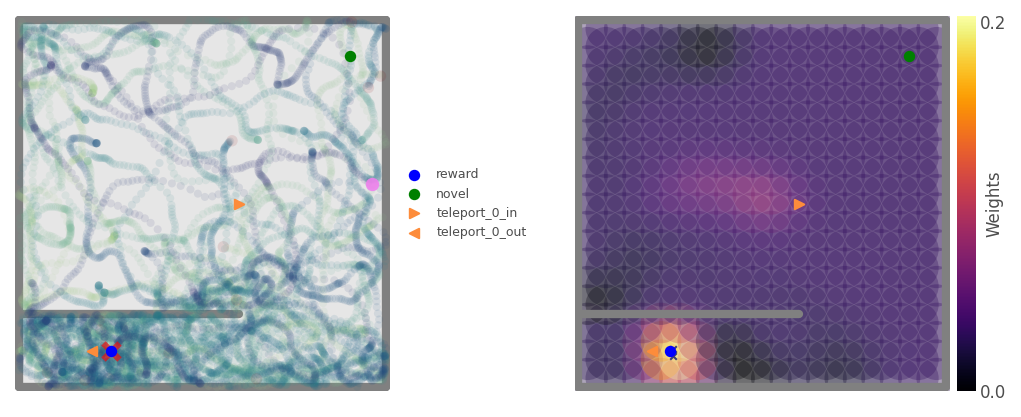

In [26]:
fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
Ag.plot_trajectories(alpha=0.1, sub_ax=ax1D[0])

plot_fcts.plot_2D_input_place_cell_weights(
    Pyrs.SomaCompartment, alpha=0.3, s=380, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
)

ALL_FIGURES["2-with_teleport_spatial"] = ax1D

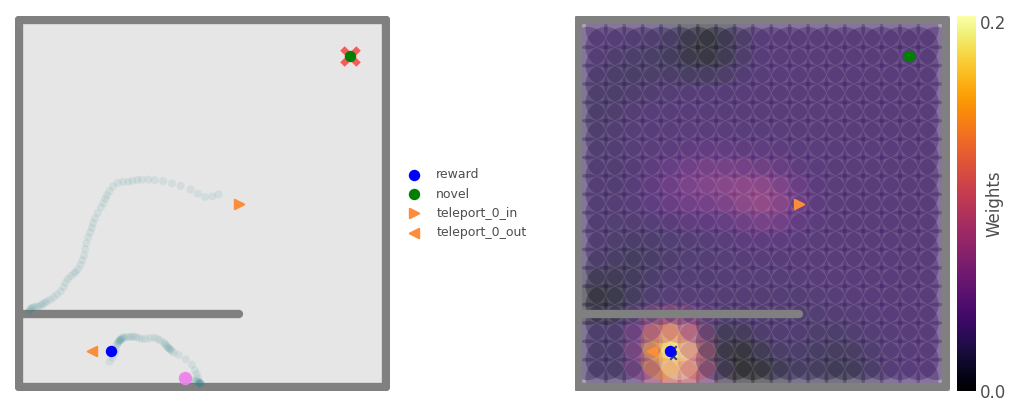

In [52]:
# visualize weights after a specific BTSP event
event_idx = 0 # from when teleport was allowed

teleport_time = Ag.teleportation_df["time"].tolist()[-1]
recorded_weights_with_teleport = learner_with_teleport.get_recorded_weights()

teleport_weights = recorded_weights_with_teleport["weights"]
teleport_weight_time = recorded_weights_with_teleport["time"]
if len(teleport_weights) > event_idx + 1:
    fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
    Ag.plot_trajectories(alpha=0.1, sub_ax=ax1D[0], t_start=teleport_time - 5, t_end=teleport_time + 5)
    
    plot_fcts.plot_2D_input_place_cell_weights(
        Pyrs.SomaCompartment, 
        place_weights=teleport_weights[event_idx + 1], 
        t_end=teleport_weight_time[event_idx + 1],
        alpha=0.3, 
        s=380,
        plot_BTSP_events=True, 
        no_legend=True, 
        ax=ax1D[1]
    )
    
    ALL_FIGURES["2-with_teleport_spatial_first"] = ax1D

In [28]:
Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
Pyrs.SomaCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 696.00 steps (20.88 sec.)
Shortest interval between applying and subsequently triggering a BTSP event in the same neuron was 19576 steps (587.28 sec.).


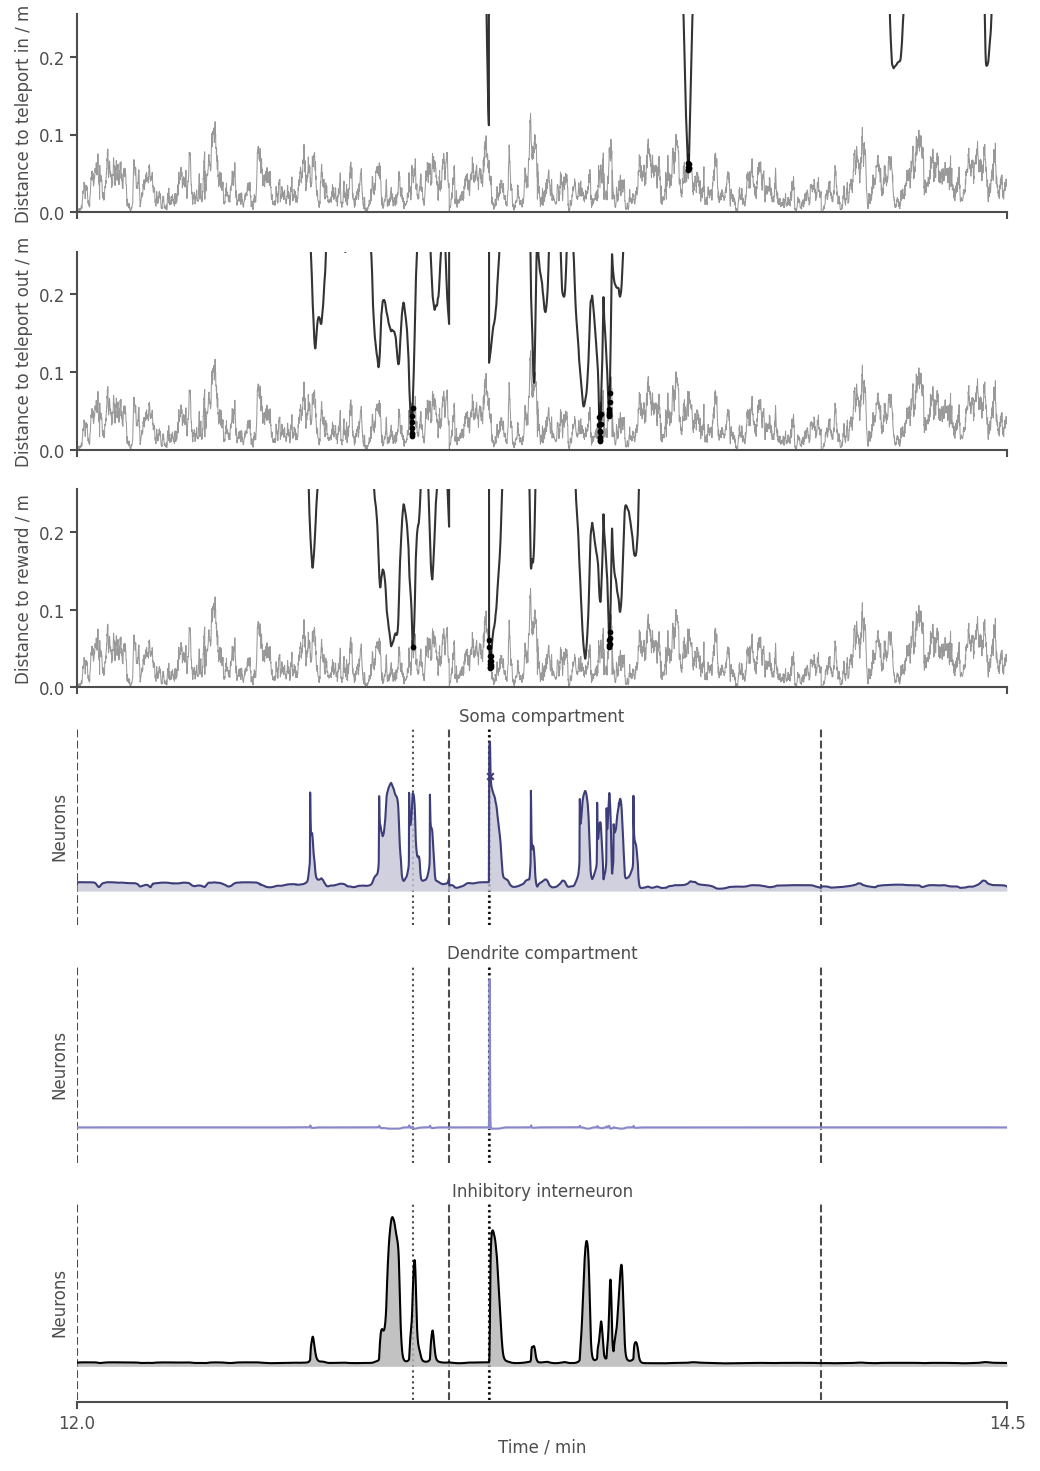

In [31]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

names = ["teleport in", "teleport out", "reward"]
plot_to_locations = list(locations["teleport_in_out"]) + [locations["reward"]]

fig, ax1D = plt.subplots(6, 1, figsize=[8, 12], sharex=True)
for i, (name, plot_to_loc) in enumerate(zip(names, plot_to_locations)):
    Ag.plot_distance_to(
        position_name=name, 
        position=copy.deepcopy(plot_to_loc), 
        sub_ax=ax1D[i],
        mark_below_tolerance=True, 
        tol_prop_to_speed_dt=tol_prop_to_speed_dt,
        zoom_prop=2,
        t_start=teleport_start_time,
    )
    ax1D[i].set_xlabel("")

Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[3:], t_start=teleport_start_time)

ALL_FIGURES["2-with_teleport_distance_to_target_single"] = ax1D

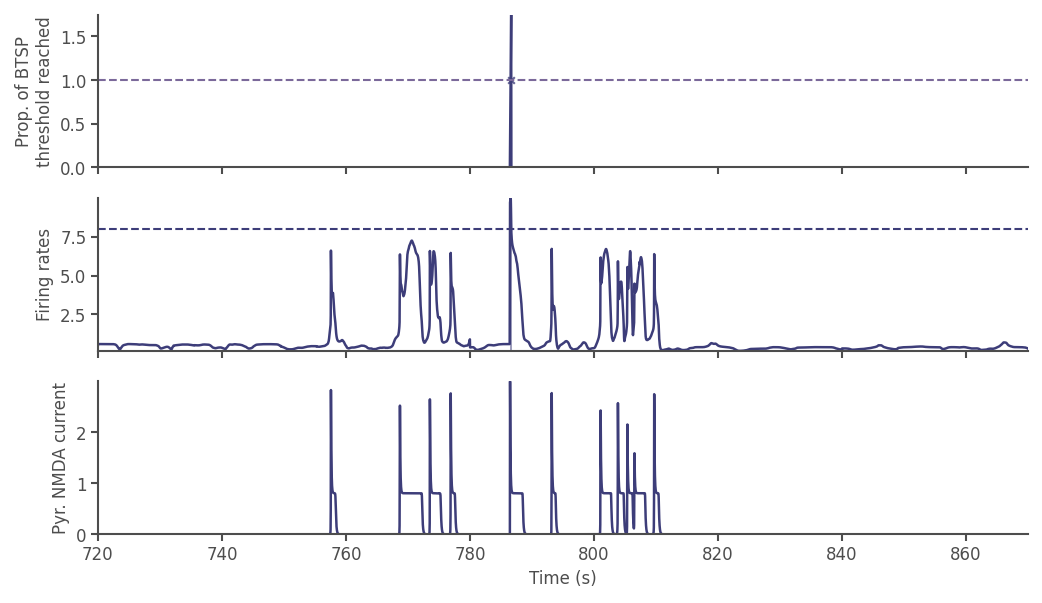

In [32]:
fig, ax1D = plt.subplots(3, 1, figsize=[8, 4.5], sharex=True)
Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D)
for sub_ax in ax1D:
    sub_ax.set_xlim(teleport_start_time, None)

ALL_FIGURES["2-with_teleport_BTSP_timeseries"] = ax1D

## 3. Save and animate

### Save figures

In [53]:
SAVE = True

In [ ]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, save=True)        

### Animate

In [55]:
ANIMATE = True

In [56]:
if ANIMATE:

    all_weight_dicts = [curr_learner.get_recorded_weights() for curr_learner in [learner, learner_with_teleport]]
    combined_weights = {
        key: np.concatenate([weight_dict[key] for weight_dict in all_weight_dicts]).tolist() 
        for key in all_weight_dicts[0].keys()
    }

    all_animate_kwargs = {
        "Pyrs": Pyrs,
        "Pyrs_weights": combined_weights["weights"],
        "Pyrs_weights_t": combined_weights["time"],
        "fps": 5,
        "speed_up": 6,
        "s": 400,
        "environment": "openfield",
        "embed_limit": 85.0,
        "autosave": True,
    }

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_end=initial_end_time, 
        savename="1-initial_timeseries",
        addendum="teleportation disabled",
        **all_animate_kwargs
    )
    anim

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=teleport_start_time,
        savename="2-with_teleport_timeseries",
        addendum="teleportation enabled",
        **all_animate_kwargs
    )
    anim